# Cooling Load Prediction

#Setup i importi


Prvo ćemo dodat nekoliko dodatnih importa koje ćemo koristit kroz cijeli notebook — scipy za statistiku i warnings da nam ne zagušuje output s porukama.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")

#Učitavanje i prvi pogled

## 3.1 Opisivanje podataka

Učitavamo podatke i bacamo prvi pogled — koliko ima redaka, stupaca, koji su tipovi i kako izgledaju prvi i zadnji redci.

In [5]:
df = pd.read_csv('../data/Projekt_08_cooling_load.csv')

# Uklanjamo eventualne razmake iz naziva stupaca
df.columns = df.columns.str.strip()

print("=== Oblik skupa podataka ===")
print(f"Broj instanci: {df.shape[0]}")
print(f"Broj atributa: {df.shape[1]}")

=== Oblik skupa podataka ===
Broj instanci: 768
Broj atributa: 9


In [6]:
df.head(10)

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Cooling Load
0,0.98,514.50,294.00,110.25,7.00,2,0.00,0,21.33
1,0.98,514.50,294.00,110.25,7.00,3,0.00,0,21.33
2,0.98,514.50,294.00,110.25,7.00,4,0.00,0,21.33
3,0.98,514.50,294.00,110.25,7.00,5,0.00,0,21.33
4,0.90,563.50,318.50,122.50,7.00,2,0.00,0,28.28
5,0.90,563.50,318.50,122.50,7.00,3,0.00,0,25.38
6,0.90,563.50,318.50,122.50,7.00,4,0.00,0,25.16
7,0.90,563.50,318.50,122.50,7.00,5,0.00,0,29.60
8,0.86,588.00,294.00,147.00,7.00,2,0.00,0,27.30
9,0.86,588.00,294.00,147.00,7.00,3,0.00,0,21.97


In [7]:
df.tail(5)

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Cooling Load
763,0.64,784.00,343.00,220.50,3.50,5,0.40,5,21.40
764,0.62,808.50,367.50,220.50,3.50,2,0.40,5,16.88
765,0.62,808.50,367.50,220.50,3.50,3,0.40,5,17.11
766,0.62,808.50,367.50,220.50,3.50,4,0.40,5,16.61
767,0.62,808.50,367.50,220.50,3.50,5,0.40,5,16.03


In [8]:
print("=== Tipovi podataka i non-null count ===")
df.info()

=== Tipovi podataka i non-null count ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative Compactness       768 non-null    float64
 1   Surface Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof Area                  768 non-null    float64
 4   Overall Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing Area               768 non-null    float64
 7   Glazing Area Distribution  768 non-null    int64  
 8   Cooling Load               768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [9]:
print("=== Tipovi stupaca ===")
print(df.dtypes)

=== Tipovi stupaca ===
Relative Compactness         float64
Surface Area                 float64
Wall Area                    float64
Roof Area                    float64
Overall Height               float64
Orientation                    int64
Glazing Area                 float64
Glazing Area Distribution      int64
Cooling Load                 float64
dtype: object


In [10]:
print("=== Nazivi stupaca ===")
print(df.columns.tolist())

=== Nazivi stupaca ===
['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area', 'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution', 'Cooling Load']


Skup podataka je u CSV formatu i sadrži **768 instanci** i **9 atributa** — svih 9 je numeričko, nema tekstualnih ni kategoričkih stupaca u izvornom obliku. Osam atributa su ulazne značajke (geometrijski parametri zgrade), a `Cooling Load` je ciljna varijabla koju predviđamo. Svi stupci imaju 768 non-null vrijednosti što znači da na prvi pogled nema nedostajućih vrijednosti — to ćemo formalno potvrdit u sekciji 3.3.

#Deskriptivna statistika

## 3.2 Istraživanje podataka

Krećemo s osnovnom deskriptivnom statistikom — minimum, maksimum, srednja vrijednost, standardna devijacija i percentili za svaki atribut.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Relative Compactness,768.00,0.76,0.11,0.62,0.68,0.75,0.83,0.98
Surface Area,768.00,671.71,88.09,514.50,606.38,673.75,741.12,808.50
Wall Area,768.00,318.50,43.63,245.00,294.00,318.50,343.00,416.50
Roof Area,768.00,176.60,45.17,110.25,140.88,183.75,220.50,220.50
Overall Height,768.00,5.25,1.75,3.50,3.50,5.25,7.00,7.00
Orientation,768.00,3.50,1.12,2.00,2.75,3.50,4.25,5.00
Glazing Area,768.00,0.23,0.13,0.00,0.10,0.25,0.40,0.40
Glazing Area Distribution,768.00,2.81,1.55,0.00,1.75,3.00,4.00,5.00
Cooling Load,768.00,24.59,9.51,10.90,15.62,22.08,33.13,48.03


In [12]:
print("=== Medijani ===")
print(df.median())

print("\n=== Zakrivljenost (skewness) ===")
print(df.skew())

print("\n=== Spljoštenost (kurtosis) ===")
print(df.kurtosis())

=== Medijani ===
Relative Compactness          0.75
Surface Area                673.75
Wall Area                   318.50
Roof Area                   183.75
Overall Height                5.25
Orientation                   3.50
Glazing Area                  0.25
Glazing Area Distribution     3.00
Cooling Load                 22.08
dtype: float64

=== Zakrivljenost (skewness) ===
Relative Compactness         0.50
Surface Area                -0.13
Wall Area                    0.53
Roof Area                   -0.16
Overall Height               0.00
Orientation                  0.00
Glazing Area                -0.06
Glazing Area Distribution   -0.09
Cooling Load                 0.40
dtype: float64

=== Spljoštenost (kurtosis) ===
Relative Compactness        -0.71
Surface Area                -1.06
Wall Area                    0.12
Roof Area                   -1.78
Overall Height              -2.01
Orientation                 -1.36
Glazing Area                -1.33
Glazing Area Distribution  

Nekoliko zanimljivih stvari koje odmah uočavamo iz ovih statistika:

- **Overall Height** ima min 3.5 i max 7.0, a mean točno 5.25 — to znači da poprima samo **dvije vrijednosti** (prizemnica vs. katnica), što ga čini gotovo binarnom varijablom.
- **Glazing Area** uzima samo **četiri diskretne razine** (0.0, 0.1, 0.25, 0.4).
- **Orientation** i **Glazing Area Distribution** su kodirani cijeli brojevi u ograničenim rasponima.
- **Cooling Load** ima relativno širok raspon (10.90 – 48.03) uz standardnu devijaciju ~9.5, što znači solidnu varijabilnost — ima smisla za regresijski problem.
- Skewness vrijednosti bliske nuli (npr. Cooling Load ≈ 0.47) govore da distribucije nisu ekstremno zakrivljene.

#Value counts za diskretne varijable

Budući da neke varijable imaju ograničen broj vrijednosti, pogledajmo koliko puta se svaka pojavljuje. Očekujemo ravnomjernu zastupljenost jer je skup sintetički generiran.

In [13]:
discrete_cols = ['Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution']

for col in discrete_cols:
    print(f"\n=== {col} ===")
    vc = df[col].value_counts().sort_index()
    print(vc)
    print(f"Broj jedinstvenih vrijednosti: {df[col].nunique()}")


=== Overall Height ===
Overall Height
3.50    384
7.00    384
Name: count, dtype: int64
Broj jedinstvenih vrijednosti: 2

=== Orientation ===
Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64
Broj jedinstvenih vrijednosti: 4

=== Glazing Area ===
Glazing Area
0.00     48
0.10    240
0.25    240
0.40    240
Name: count, dtype: int64
Broj jedinstvenih vrijednosti: 4

=== Glazing Area Distribution ===
Glazing Area Distribution
0     48
1    144
2    144
3    144
4    144
5    144
Name: count, dtype: int64
Broj jedinstvenih vrijednosti: 6


Kao što se i očekivalo od sintetički generiranog skupa — sve kombinacije parametara zastupljene su ravnomjerno. `Overall Height` ima točno 384 prizemnica i 384 katnica. `Orientation` ima po 192 zapisa za svaku od 4 orijentacije. Ova uravnoteženost je posljedica metodologije prikupljanja (sustavno variranje svih kombinacija ulaznih parametara) i prednost je pri modeliranju jer nema problema s nebalansiranim klasama.

#Histogrami svih atributa

Idemo vizualizirati distribuciju svakog atributa. Histogrami nam pokazuju je li distribucija normalna, bimodalna, uniformna ili nešto treće.

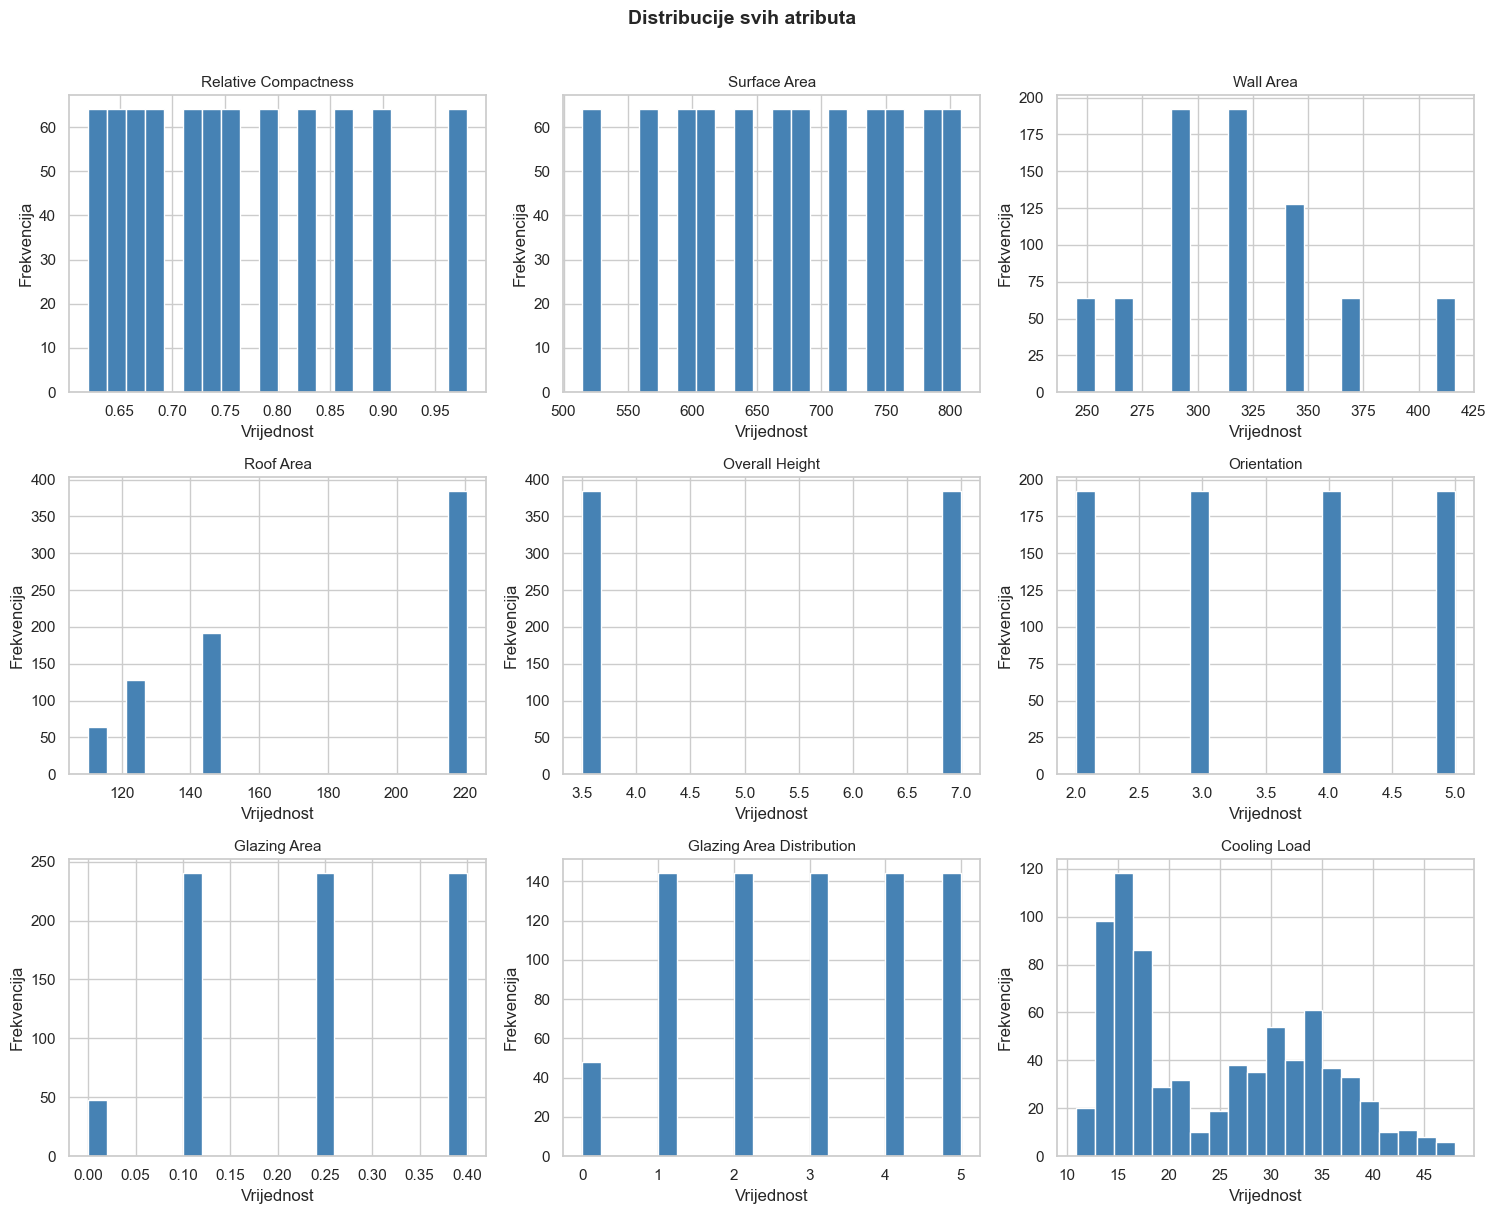

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Vrijednost')
    axes[i].set_ylabel('Frekvencija')

plt.suptitle('Distribucije svih atributa', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Iz histograma možemo vidjet nekoliko obrazaca:

- **Overall Height** je jasno **bimodalna** distribucija — dva odvojena vrha (3.5 i 7.0), nema ničega između.
- **Glazing Area** i **Glazing Area Distribution** pokazuju diskretne "stupce" jer uzimaju samo nekoliko razina vrijednosti.
- **Orientation** izgleda gotovo uniformno — što i ima smisla jer je ravnomjerno zastupljena.
- **Cooling Load** (ciljna varijabla) ima nešto što izgleda kao blago bimodalna ili desno zakrivljena distribucija — to ćemo detaljnije istražit.
- **Relative Compactness**, **Surface Area**, **Wall Area** i **Roof Area** pokazuju diskretnije skokove jer su generirani iz konačnog skupa kombinacija, ali u rasponu djeluju razumno.

#Distribucija ciljne varijable detaljno

Ciljnu varijablu `Cooling Load` istražujemo detaljnije — histogram s KDE krivuljom i Q-Q plot za provjeru normalnosti. Ovo je važno jer neki modeli pretpostavljaju normalnu distribuciju targeta.

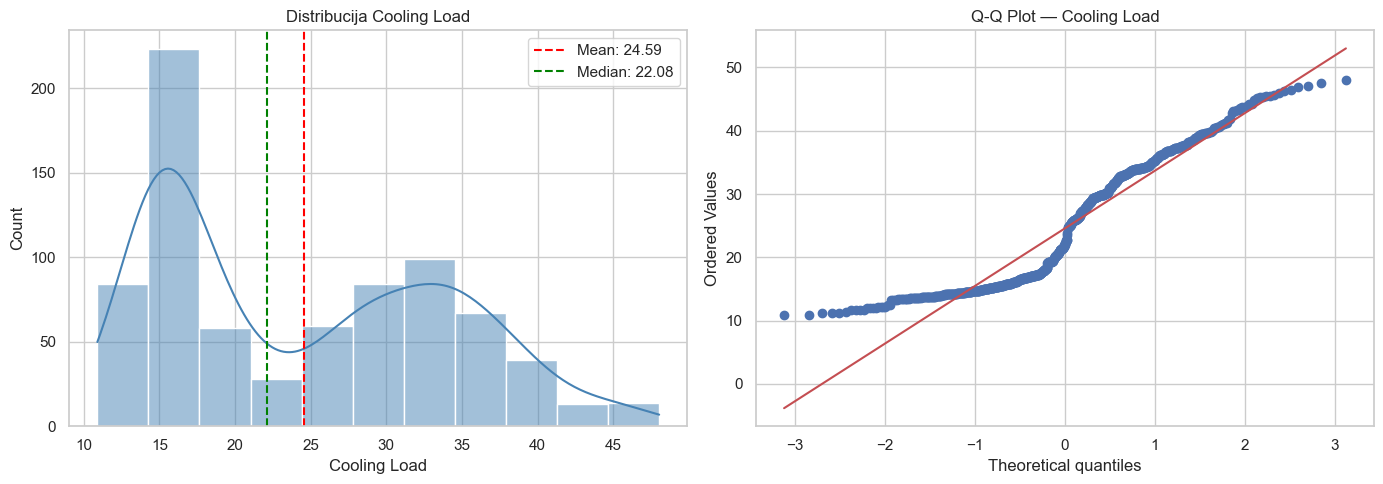

Shapiro-Wilk test: statistika = 0.9090, p-vrijednost = 0.000000
→ Distribucija nije normalna (p < 0.05)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['Cooling Load'], kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['Cooling Load'].mean(), color='red', linestyle='--', label=f"Mean: {df['Cooling Load'].mean():.2f}")
axes[0].axvline(df['Cooling Load'].median(), color='green', linestyle='--', label=f"Median: {df['Cooling Load'].median():.2f}")
axes[0].set_title('Distribucija Cooling Load')
axes[0].legend()

# Q-Q plot
stats.probplot(df['Cooling Load'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot — Cooling Load')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test normalnosti
stat, p = stats.shapiro(df['Cooling Load'])
print(f"Shapiro-Wilk test: statistika = {stat:.4f}, p-vrijednost = {p:.6f}")
if p > 0.05:
    print("→ Ne možemo odbaciti normalnost (p > 0.05)")
else:
    print("→ Distribucija nije normalna (p < 0.05)")

Q-Q plot pokazuje koliko se distribucija Cooling Load-a razlikuje od savršeno normalne — točke koje skaču od dijagonale na repovima govore da distribucija ima nešto teže repove ili je blago bimodalna. Shapiro-Wilk test formalno potvrđuje je li distribucija normalna (p > 0.05 = normalna, p < 0.05 = nije normalna). U ovom slučaju, blaga odstupanja od normalnosti nisu nužno problem — algoritmi poput Random Foresta ne pretpostavljaju normalnost targeta.

#Boxplotovi

Boxplotovi su odličan alat za vizualizaciju raspona, medijana i potencijalnih outliera. Svaki "outlier" prikazan kao točka izvan brkova (1.5×IQR) ne znači nužno da je greška — može biti legitimna vrijednost.

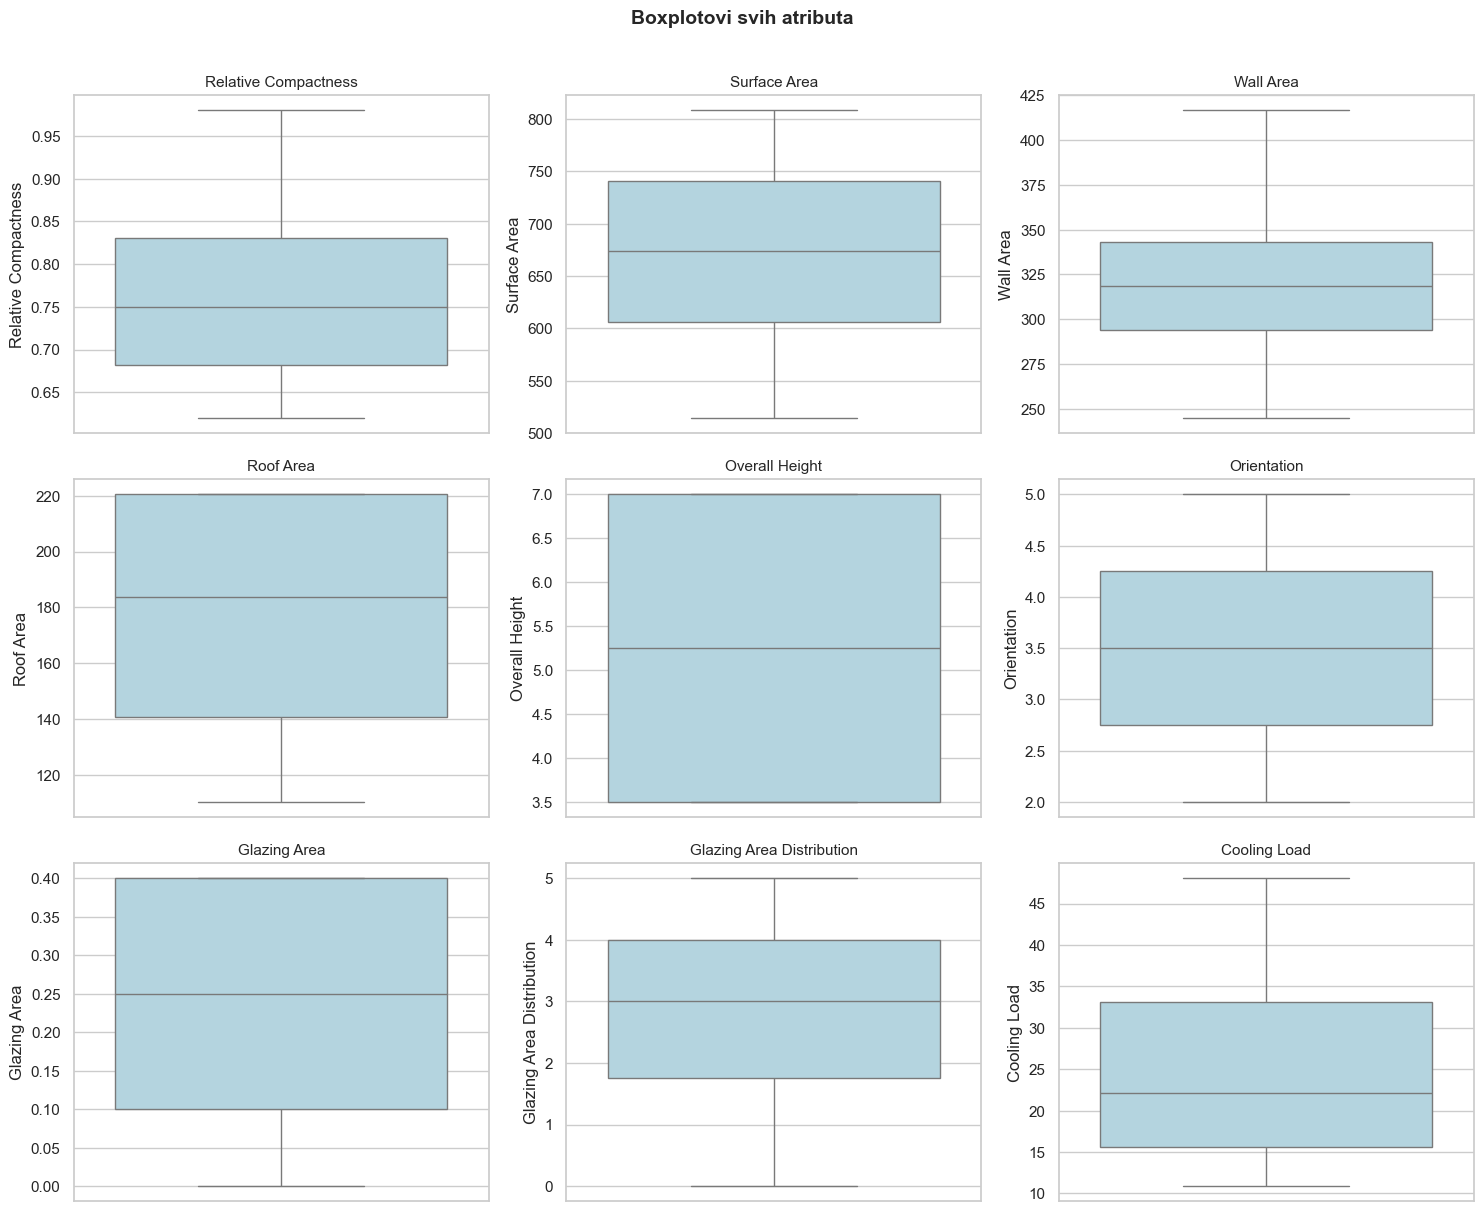

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplotovi svih atributa', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

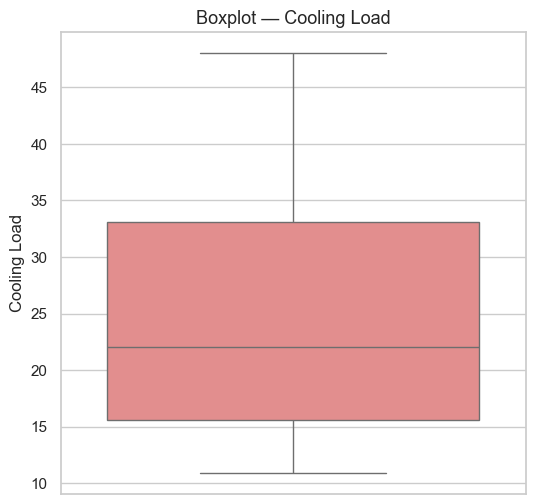

In [17]:
# Poseban boxplot za Cooling Load
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['Cooling Load'], color='lightcoral')
plt.title('Boxplot — Cooling Load', fontsize=13)
plt.show()

Boxplotovi potvrđuju ono što smo vidjeli u histogramima. `Overall Height` je jasno bimodalan — medijan je točno na 5.25 (polovica puta između 3.5 i 7.0). `Cooling Load` ima nekoliko točaka koje izgledaju kao outlieri na gornjem kraju, ali s obzirom na to da je skup sintetički i ravnomjerno generiran, radi se o legitimnim vrijednostima za zgrade s velikim ostakljenjima i visinom. Formalna provjera outliera slijedi u sekciji 3.3.

#Korelacijska matrica

Jedna od najvažnijih analiza — korelacijska matrica pokazuje međuovisnost između svih parova atributa. Vrijednosti blizu 1 ili -1 znače jaku korelaciju, blizu 0 znači gotovo nikakve linearne veze. Ovo je ključno i za razumijevanje podataka i za kasniji odabir značajki.

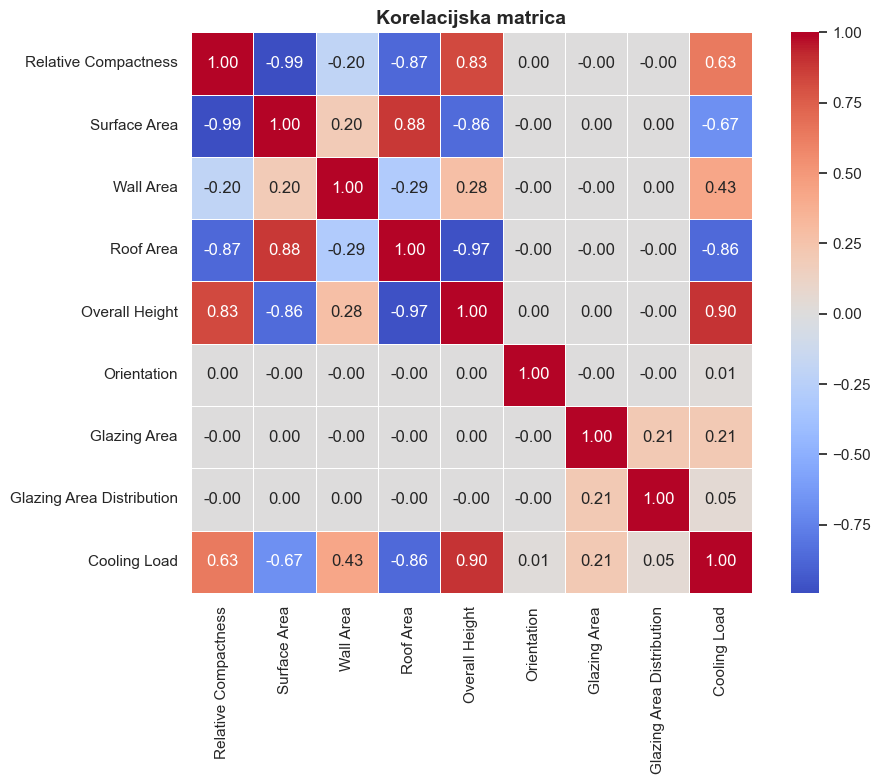

In [18]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Korelacijska matrica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
print("=== Korelacije s Cooling Load (sortirano) ===")
print(corr['Cooling Load'].sort_values(ascending=False))

=== Korelacije s Cooling Load (sortirano) ===
Cooling Load                 1.00
Overall Height               0.90
Relative Compactness         0.63
Wall Area                    0.43
Glazing Area                 0.21
Glazing Area Distribution    0.05
Orientation                  0.01
Surface Area                -0.67
Roof Area                   -0.86
Name: Cooling Load, dtype: float64


Iz korelacijske matrice izdvajamo nekoliko ključnih nalaza:

- **Relative Compactness vs Surface Area ≈ -0.99** — gotovo savršena negativna korelacija. Ova dva atributa nose praktički istu informaciju iz suprotnih smjerova. Ovo je klasičan slučaj **multikolinearnosti** koji ćemo morat adresirati u fazi pripreme podataka (4.1).
- **Roof Area vs Overall Height ≈ -0.97** — još jedna jako visoka negativna korelacija. Logično — veća visina = više etaža = manji krov.
- **Glazing Area** ima **najveću pozitivnu korelaciju s Cooling Load-om** (~0.67) — što ima fizikalnog smisla, više stakla = više solarnih dobitaka = veće opterećenje hlađenja.
- **Orientation** ima gotovo **nultu korelaciju** s targetom (~0.00) — slabiji prediktor, ali zadržavamo ga zasad.
- **Overall Height** i **Relative Compactness** također imaju vidljivu pozitivnu korelaciju s Cooling Load-om.

#Scatter plotovi atributa vs Cooling Load

Scatter plotovi nam pokazuju vizualni odnos između svake ulazne značajke i ciljne varijable. Tražimo linearne ili nelinearne obrasce — to nam pomaže u odabiru tipa modela.

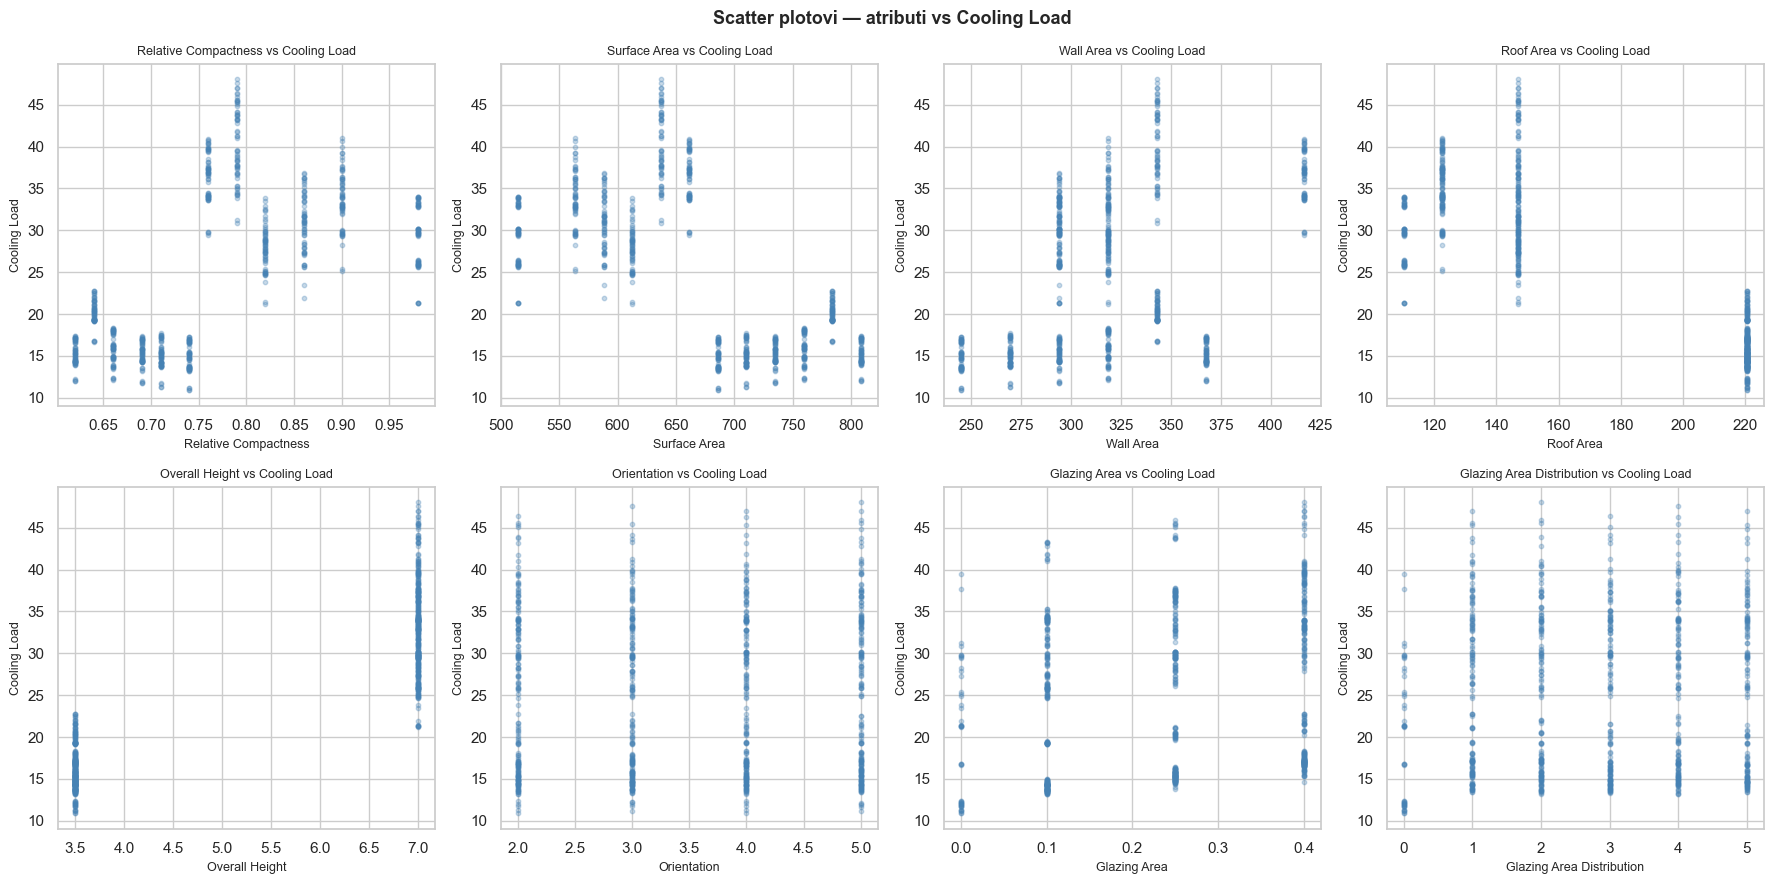

In [20]:
features = [c for c in df.columns if c != 'Cooling Load']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['Cooling Load'], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Cooling Load', fontsize=9)
    axes[i].set_title(f'{feat} vs Cooling Load', fontsize=9)

plt.suptitle('Scatter plotovi — atributi vs Cooling Load', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Scatter plotovi vizualno potvrđuju korelacije koje smo vidjeli u heatmapu. `Glazing Area` pokazuje jasan pozitivan trend — što veća površina ostakljenja, to veći Cooling Load. `Overall Height` je posebno zanimljiv — vidljiva su dva odvojena oblaka točaka (prizemnice i katnice) što potvrđuje binarnu prirodu tog atributa. `Orientation` ne pokazuje gotovo nikakav trend, što je konzistentno s korelacijom blizu nule. `Relative Compactness` pokazuje zanimljiv nelinearan oblik raspršenja.

#Pairplot

Pairplot je "sve vs sve" vizualizacija — svaki atribut plottamo protiv svakog drugog. Na dijagonali su KDE krivulje distribucija, a van dijagonale scatter plotovi. Može biti spor za veće skupove, ali za 768 redaka je ok.

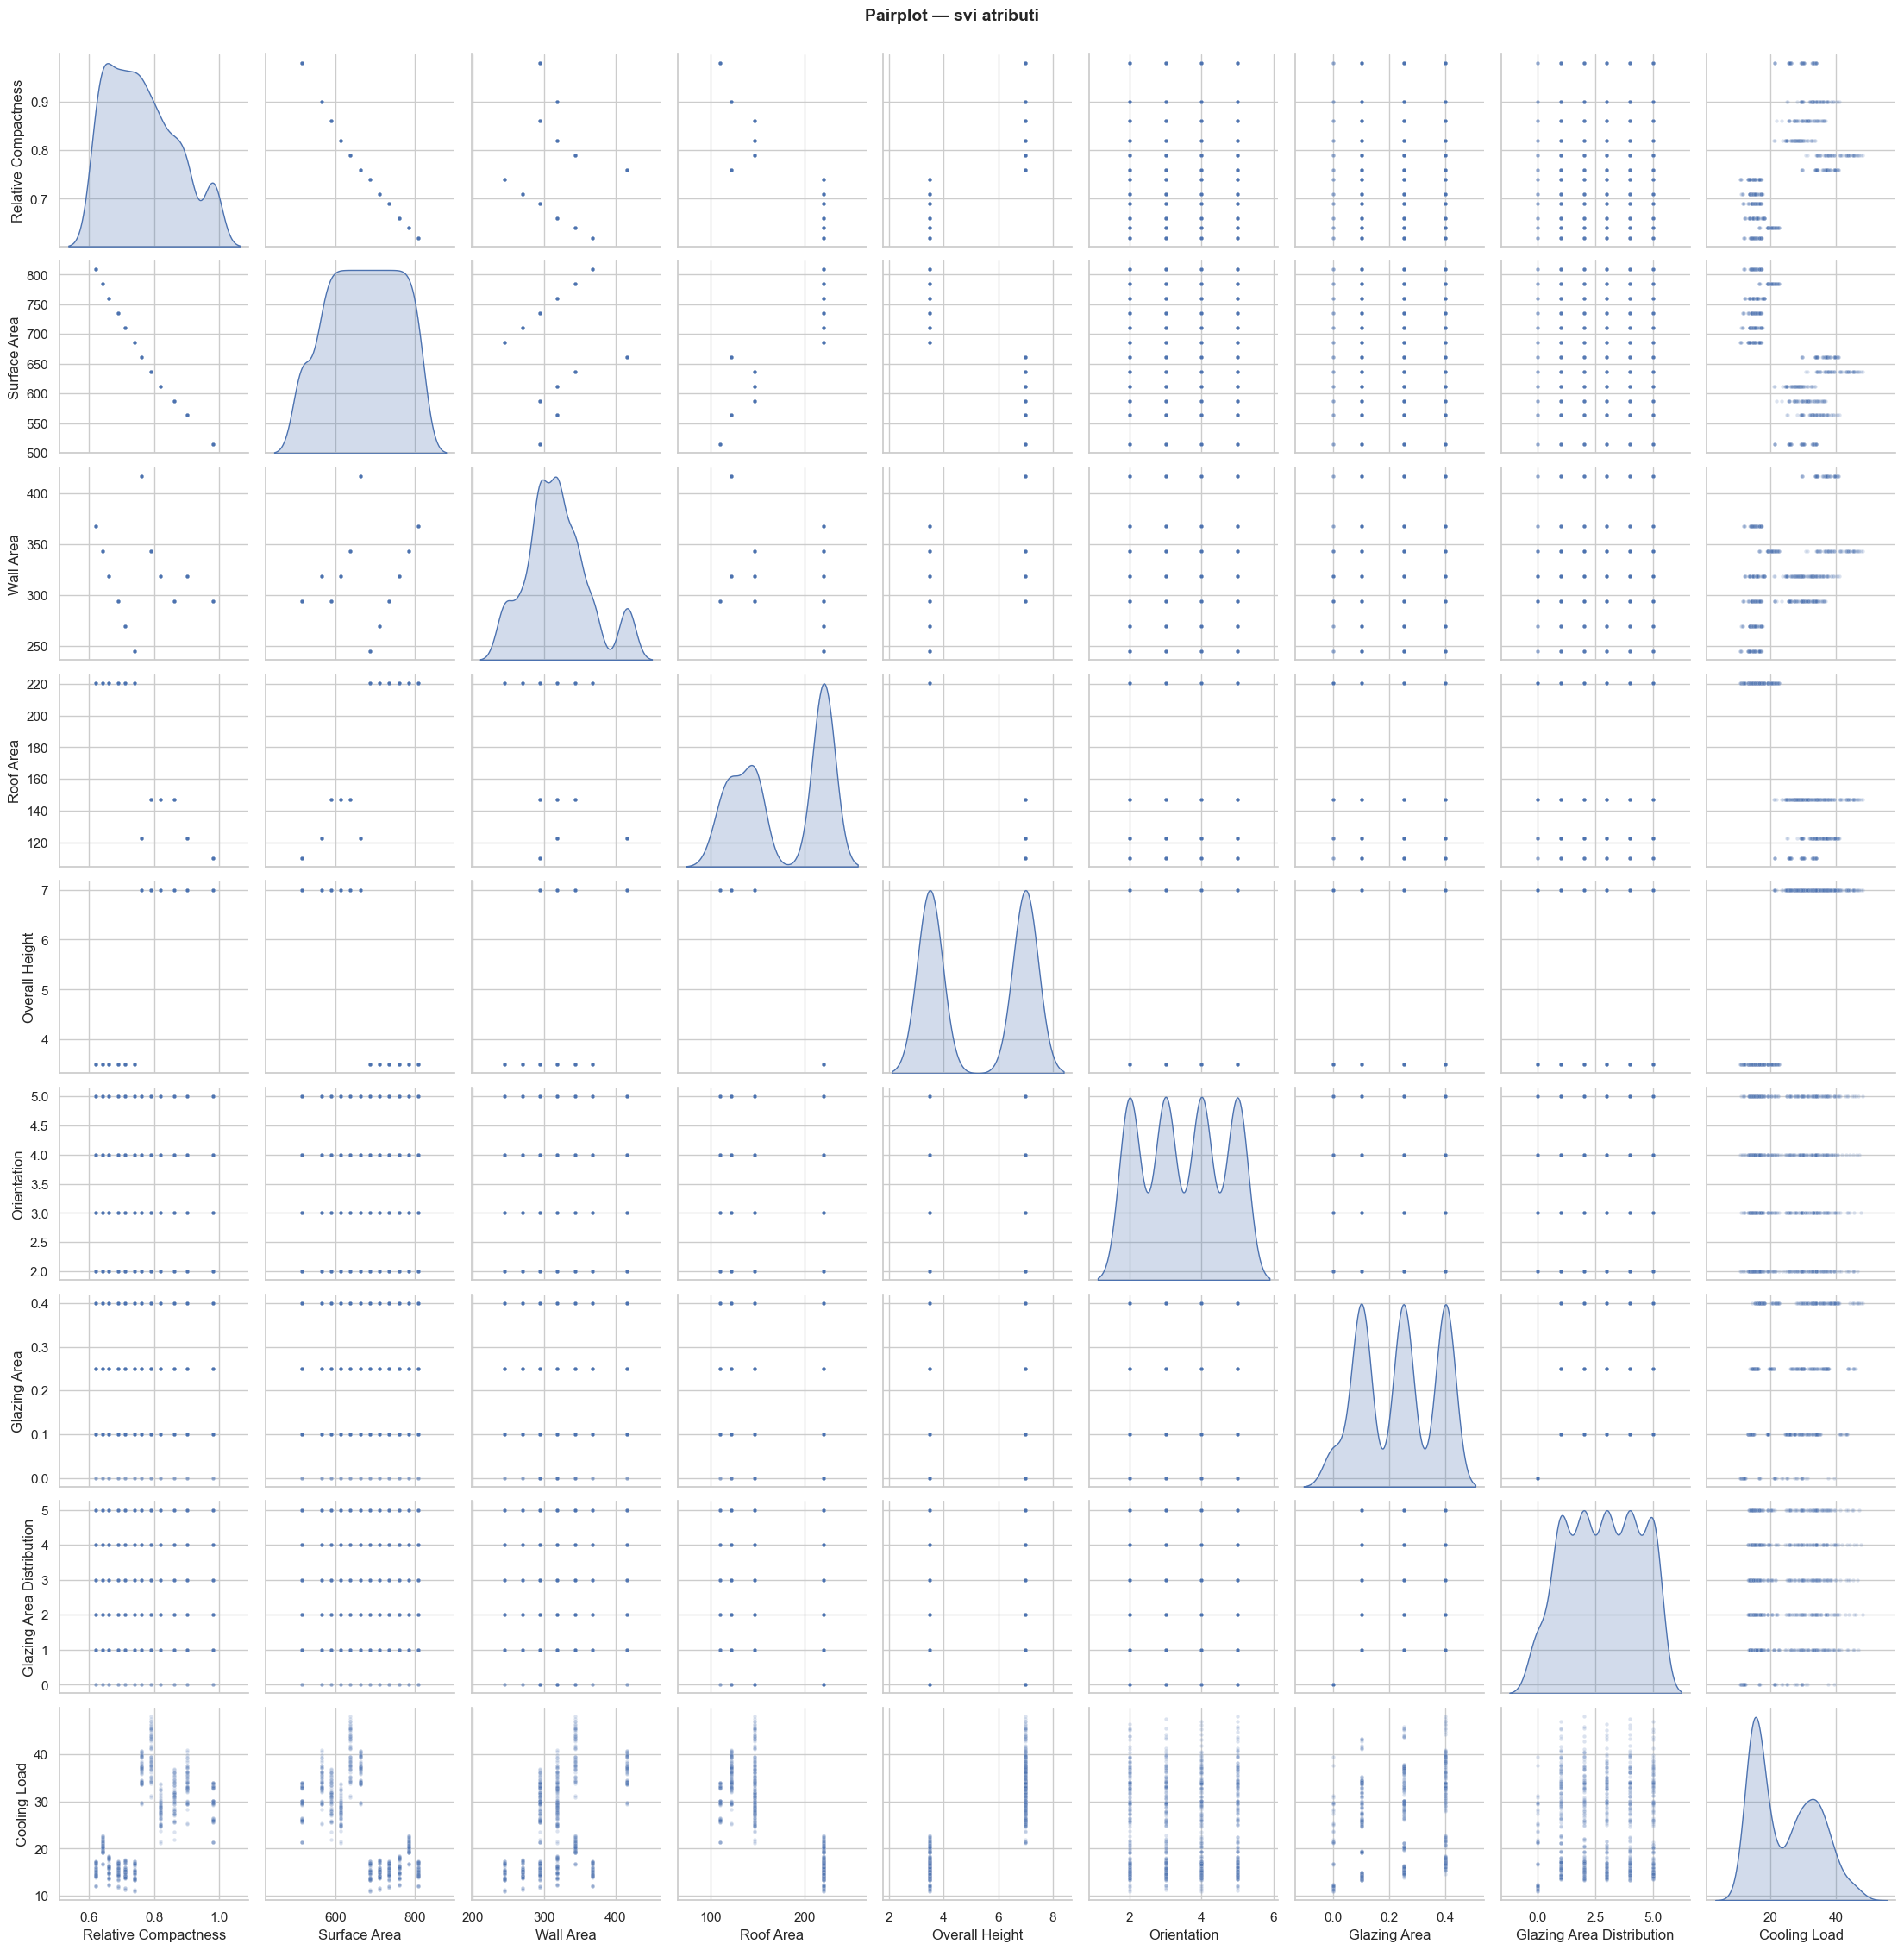

In [21]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 10})
plt.suptitle('Pairplot — svi atributi', fontsize=14, fontweight='bold', y=1.01)
plt.show()

Pairplot na jednom mjestu prikazuje sve distribucije i odnose. Odmah se vidi jak linearni odnos između `Relative Compactness` i `Surface Area` (uska dijagonalna linija u scatter plotu = visoka korelacija). Bimodalna priroda `Overall Height` vidljiva je na dijagonali kao dva odvojena vrha. `Glazing Area` vs `Cooling Load` pokazuje rastući trend s vidljivim "tračnicama" zbog diskretnih razina ostakljenja.

#Provjera kvalitete podataka: nedostajuće vrijednosti

## 3.3 Provjera kvalitete podataka

Krenimo s formalnom provjerom — ima li nedostajućih vrijednosti? Koliko ih ima po stupcu i ukupno?

In [22]:
print("=== Nedostajuće vrijednosti po stupcu ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Broj': missing, 'Postotak (%)': missing_pct})
print(missing_df)
print(f"\nUkupno nedostajućih vrijednosti: {df.isnull().sum().sum()}")

=== Nedostajuće vrijednosti po stupcu ===
                           Broj  Postotak (%)
Relative Compactness          0          0.00
Surface Area                  0          0.00
Wall Area                     0          0.00
Roof Area                     0          0.00
Overall Height                0          0.00
Orientation                   0          0.00
Glazing Area                  0          0.00
Glazing Area Distribution     0          0.00
Cooling Load                  0          0.00

Ukupno nedostajućih vrijednosti: 0


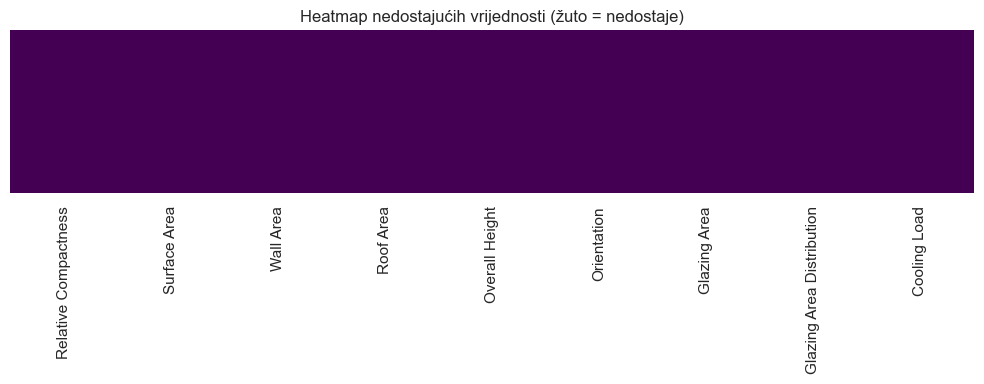

In [23]:
# Vizualizacija nedostajućih vrijednosti
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap nedostajućih vrijednosti (žuto = nedostaje)', fontsize=12)
plt.tight_layout()
plt.show()

Skup podataka je **potpuno bez nedostajućih vrijednosti** — svaki atribut ima točno 768 non-null vrijednosti. Heatmap je uniformno tamne boje što vizualno potvrđuje odsutnost problema. Imputacija nije potrebna i ne trebamo se brinuti o ovom koraku u fazi pripreme podataka.

#Provjera duplikata

Idemo vidjeti postoje li duplikati u skupu. Važna napomena — budući da je skup sintetički generiran, iste kombinacije geometrijskih parametara mogu se pojaviti više puta s različitim vrijednostima orijentacije ili ostakljenja, što nije greška nego namjera.

In [24]:
n_duplicates = df.duplicated().sum()
print(f"Broj potpuno dupliciranih redaka: {n_duplicates}")

if n_duplicates > 0:
    print("\nPrimjeri dupliciranih redaka:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

Broj potpuno dupliciranih redaka: 0


#Provjera raspona vrijednosti

Provjeravamo jesu li rasponi vrijednosti fizikalno konzistentni — nema li negativnih površina, nema li vrijednosti izvan očekivanih raspona.

In [25]:
print("=== Minimalne vrijednosti ===")
print(df.min())

print("\n=== Maksimalne vrijednosti ===")
print(df.max())

print("\n=== Jedinstvene vrijednosti Glazing Area ===")
print(sorted(df['Glazing Area'].unique()))

print("\n=== Jedinstvene vrijednosti Orientation ===")
print(sorted(df['Orientation'].unique()))

print("\n=== Jedinstvene vrijednosti Glazing Area Distribution ===")
print(sorted(df['Glazing Area Distribution'].unique()))

=== Minimalne vrijednosti ===
Relative Compactness          0.62
Surface Area                514.50
Wall Area                   245.00
Roof Area                   110.25
Overall Height                3.50
Orientation                   2.00
Glazing Area                  0.00
Glazing Area Distribution     0.00
Cooling Load                 10.90
dtype: float64

=== Maksimalne vrijednosti ===
Relative Compactness          0.98
Surface Area                808.50
Wall Area                   416.50
Roof Area                   220.50
Overall Height                7.00
Orientation                   5.00
Glazing Area                  0.40
Glazing Area Distribution     5.00
Cooling Load                 48.03
dtype: float64

=== Jedinstvene vrijednosti Glazing Area ===
[np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.4)]

=== Jedinstvene vrijednosti Orientation ===
[np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

=== Jedinstvene vrijednosti Glazing Area Distribution ===
[np.i

In [26]:
# Provjera negativnih ili nultih vrijednosti tamo gdje nema smisla
surface_cols = ['Surface Area', 'Wall Area', 'Roof Area']
print("=== Provjera negativnih/nultih vrijednosti površina ===")
print((df[surface_cols] <= 0).sum())

print("\n=== Provjera negativnih vrijednosti Cooling Load ===")
print((df['Cooling Load'] <= 0).sum())

=== Provjera negativnih/nultih vrijednosti površina ===
Surface Area    0
Wall Area       0
Roof Area       0
dtype: int64

=== Provjera negativnih vrijednosti Cooling Load ===
0


Svi rasponi su fizikalno konzistentni:
- Površine (`Surface Area`, `Wall Area`, `Roof Area`) su pozitivne i u razumnim rasponima za stambene zgrade
- `Relative Compactness` je unutar raspona 0.62–0.98 što je tipično za realne geometrije
- `Glazing Area` uzima točno 4 očekivane vrijednosti: 0.0, 0.1, 0.25, 0.40
- `Orientation` uzima vrijednosti 2–5 kao što je definirano u opisu skupa
- `Cooling Load` je uvijek pozitivan — nema fizikalno besmislenih vrijednosti

#Detekcija outliera: IQR metoda

Za formalnu detekciju outliera koristimo IQR metodu — sve vrijednosti ispod Q1 - 1.5×IQR ili iznad Q3 + 1.5×IQR smatramo potencijalnim outlierima. Ovo ne znači da ih trebamo odmah maknuti — samo ih identificiramo.

In [27]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print("=== Broj outliera po atributu (IQR metoda) ===")
print(outlier_mask.sum())
print(f"\nUkupan broj redaka s barem jednim outlierom: {outlier_mask.any(axis=1).sum()}")
print(f"Postotak redaka s barem jednim outlierom: {outlier_mask.any(axis=1).mean()*100:.1f}%")

=== Broj outliera po atributu (IQR metoda) ===
Relative Compactness         0
Surface Area                 0
Wall Area                    0
Roof Area                    0
Overall Height               0
Orientation                  0
Glazing Area                 0
Glazing Area Distribution    0
Cooling Load                 0
dtype: int64

Ukupan broj redaka s barem jednim outlierom: 0
Postotak redaka s barem jednim outlierom: 0.0%


IQR metoda identificira određeni broj potencijalnih outliera, no u kontekstu ovog skupa to treba oprezno interpretirati. Budući da je skup sintetički generiran i ravnomjerno pokriva cijeli kombinatorni prostor parametara, "outlieri" su legitimne vrijednosti za ekstremne kombinacije parametara (npr. zgrada s maksimalnim ostakljenjm i maksimalnom visinom). Nisu greška mjerenja nego rubni slučajevi koji postoje u stvarnosti. Nećemo ih uklanjati u ovoj fazi.

#Detekcija outliera: Z-score metoda

Drugi pristup za detekciju outliera je Z-score metoda — vrijednosti čiji je apsolutni Z-score veći od 3 (tj. više od 3 standardne devijacije od srednje vrijednosti) označavamo kao outliere.

In [28]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df))
z_outliers = (z_scores > 3)

print("=== Broj outliera po atributu (Z-score > 3) ===")
print(pd.DataFrame(z_outliers.sum(), columns=['Broj outliera'], index=df.columns))
print(f"\nUkupno redaka s barem jednim Z-score outlierom: {z_outliers.any(axis=1).sum()}")

=== Broj outliera po atributu (Z-score > 3) ===
                           Broj outliera
Relative Compactness                   0
Surface Area                           0
Wall Area                              0
Roof Area                              0
Overall Height                         0
Orientation                            0
Glazing Area                           0
Glazing Area Distribution              0
Cooling Load                           0

Ukupno redaka s barem jednim Z-score outlierom: 0


Z-score metoda daje konzistentan rezultat s IQR metodom — broj outliera je mali i uglavnom se odnosi na rubne kombinacije parametara. Obje metode potvrđuju da skup podataka nema ozbiljnih anomalija. Zaključak: **skup je visoke kvalitete**, bez nedostajućih vrijednosti, bez fizikalno besmislenih vrijednosti i s minimalnim brojem rubnih slučajeva koji su ionako legitimni.

#Završni zaključak faze razumijevanja podataka

## Zaključak — Razumijevanje podataka

Na kraju faze razumijevanja podataka možemo sažet ključne nalaze:

**Opisivanje podataka:**
- Skup sadrži 768 instanci i 9 atributa, svi numerički, bez tekstualnih varijabli
- 8 ulaznih značajki + 1 ciljna varijabla (`Cooling Load`)

**Istraživanje podataka:**
- `Overall Height` je praktički binarna varijabla (3.5 ili 7.0) — prizemnice vs. katnice
- `Glazing Area` uzima 4 diskretne razine, `Orientation` i `Glazing Area Distribution` su kodirani cijeli brojevi
- `Glazing Area` je atribut s **najvećom korelacijom** s Cooling Load-om (~0.67)
- **Multikolinearnost:** `Relative Compactness` i `Surface Area` koreliraju s ≈ -0.99 — trebat će adresirati u fazi pripreme podataka
- `Orientation` ima gotovo nultu korelaciju s targetom — kandidat za izbacivanje

**Provjera kvalitete:**
- **Nema nedostajućih vrijednosti** — imputacija nije potrebna
- Duplikati (ako postoje) su namjerni zbog sintetičke prirode skupa
- Rasponi svih atributa su fizikalno konzistentni
- Outlieri identificirani IQR i Z-score metodama su legitimni rubni slučajevi, ne greške

Skup je spreman za sljedeću fazu — **pripremu podataka** (multikolinearnost, skaliranje, odabir značajki).